#  Einführung in PyTorch am Beispiel von FashionMNIST

rows: 4, cols: 5






















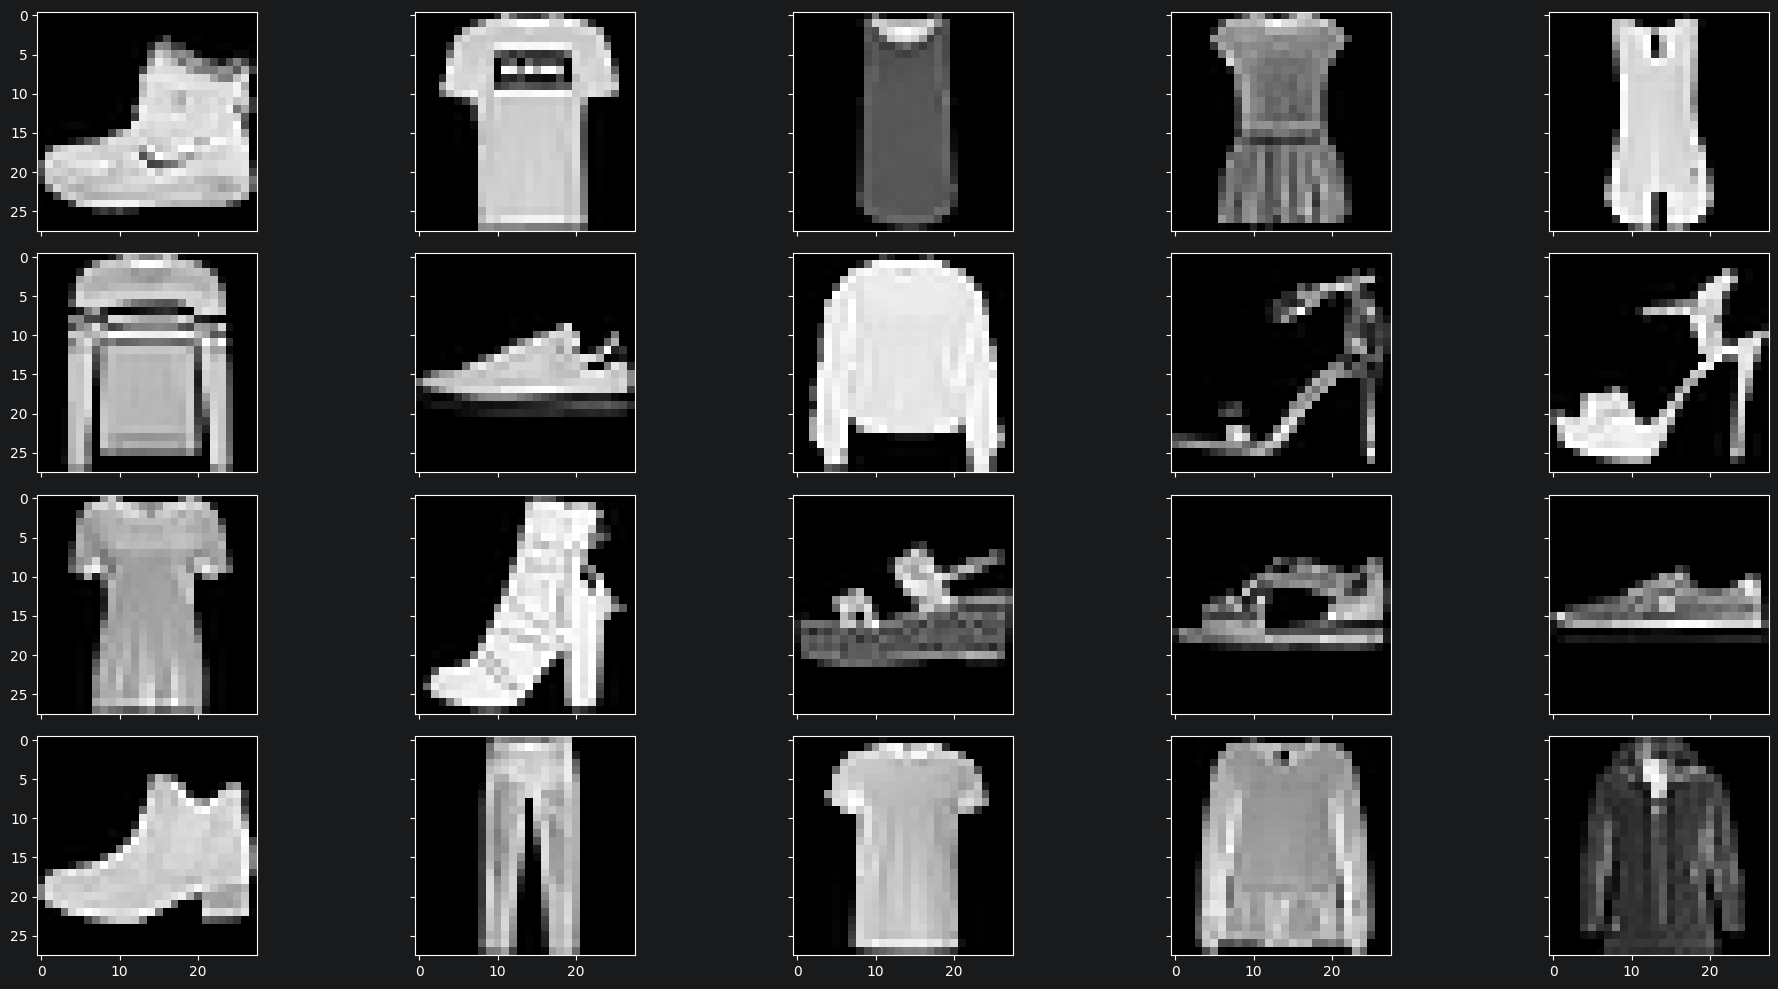

In [1]:
import logging
import math
import time

import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


def default_log(log_string):
    """Default sink for :func:`get_print_logger`; prints formatted log lines to stdout."""
    print(f"{log_string}")
    # print(f"------------------------ \n{log_string}")


class FunctionHandler(logging.Handler):
    """Logging handler that forwards formatted records to a custom callable."""

    def __init__(self, sink_function):
        super().__init__()
        self.sink_function = sink_function

    def emit(self, record):
        """Format ``record`` and pass the result to ``sink_function``."""
        try:
            msg = self.format(record)
            self.sink_function(msg)
        except Exception:
            self.handleError(record)


# Name used by logging.getLogger(); tune levels via logging.getLogger(DEFAULT_LOGGER_NAME)
DEFAULT_LOGGER_NAME = "deep learning"


def get_print_logger(
        name=DEFAULT_LOGGER_NAME,
        msg_producer=default_log,
        level=logging.DEBUG,
        ):
    """Return a logger that forwards formatted records to ``msg_producer`` instead of stderr."""
    logger = logging.getLogger(name)
    logger.setLevel(level)

    if logger.handlers:
        logger.handlers.clear()

    handler = FunctionHandler(msg_producer)

    formatter = logging.Formatter(
            fmt="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            )
    handler.setFormatter(formatter)
    logger.addHandler(handler)

    return logger


default_logger = get_print_logger()


def plot_samples(data,
                 n=5,
                 max_cols=5,
                 cmap="tab20"
                 ):
    n = min(len(data), n)
    if n < max_cols:
        rows = 1
        cols = n
    else:
        rows = math.ceil(n / max_cols)
        cols = max_cols
    print(f"rows: {rows}, cols: {cols}")
    fig, ax = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(20, 10))
    #ax = ax.flatten()
    index = 0
    for i in range(rows):
        for j in range(cols):
            img = data[index]
            index += 1
            #    .numpy().reshape(X.shape[1],X.shape[2],2)
            print()
            ax[i, j].imshow(img, cmap=cmap, interpolation='nearest')
            if index >= n:
                break

    #ax[0].set_xticks([])
    #ax[0].set_yticks([])
    plt.tight_layout()
    # plt.savefig('./figures/mnist_all.png', dpi=300)
    plt.show()


training_data = datasets.FashionMNIST(
        root="data",
        train=True,
        download=True,
        transform=ToTensor()
        )

test_data = datasets.FashionMNIST(
        root="data",
        train=False,
        download=True,
        transform=ToTensor()
        )
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

plot_samples(training_data.data, n=20, cmap="gray")


In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [3]:
# Das Modell gibt logits zurück. CrossEntropyLoss erwartet logits.
# Softmax verwenden wir nur, wenn wir Wahrscheinlichkeiten anzeigen wollen.

class NeuralNetwork(nn.Module):
    def __init__(self, nr_neurons=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
                nn.Linear(28 * 28, nr_neurons),
                nn.ReLU(),
                nn.Linear(nr_neurons, nr_neurons),
                nn.SELU(),
                nn.Linear(nr_neurons, 10)
                )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits



In [6]:
model = NeuralNetwork().to(device)
X = torch.rand(1, 28, 28, device=device)
print(X.shape)
logits = model(X)
print(logits)
pred_probab = nn.Softmax(dim=1)(logits)
print(pred_probab)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

torch.Size([1, 28, 28])
tensor([[ 0.0400, -0.3143,  0.0370, -0.1595,  0.0431,  0.0376,  0.0812, -0.1092,
          0.0243,  0.0255]], device='mps:0', grad_fn=<LinearBackward0>)
tensor([[0.1065, 0.0747, 0.1062, 0.0872, 0.1068, 0.1062, 0.1109, 0.0917, 0.1048,
         0.1049]], device='mps:0', grad_fn=<SoftmaxBackward0>)
Predicted class: tensor([6], device='mps:0')


## Ein Trainingsschritt

In [7]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

In [11]:
X = train_dataloader.dataset[0][0].to(device)
print(X.shape)
y = train_dataloader.dataset[0][1]
print(f"Class: {y}")
y = torch.tensor(y).to(device)
y = y.reshape(1, )
print(y.shape)
model.train()
pred = model(X)
loss = loss_fn(pred, torch.tensor(y).to(device))
print(f"Predicted class: {pred.argmax(1)}")
print(f"Loss: {loss.item()}")
# Backpropagation
loss.backward()
optimizer.step()
optimizer.zero_grad()

torch.Size([1, 28, 28])
Class: 9
torch.Size([1])
Predicted class: tensor([9], device='mps:0')
Loss: 1.793185830116272


/var/folders/fn/631f5l8d60s9dlhzgthzclk80000gn/T/ipykernel_65358/4117301650.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = loss_fn(pred, torch.tensor(y).to(device))


In [13]:
def train(model, train_dl, epochs, eval_dl=None, logger=default_logger, filename=None):
    """Train ``model`` and return metrics collected during training."""
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
    model_device = next(model.parameters()).device
    train_size = len(train_dl.dataset)

    history = {
            "loss": [],
            "accuracy": [],
            "training_time": [],
            "batch_loss": [],
            "eval_loss": [],
            "eval_accuracy": [],
            "eval_time": [],
            "epoch_time": [],
            }
    total_training_time = 0
    total_eval_time = 0

    for epoch in range(epochs):
        logger.info(f"Epoch {epoch + 1}/{epochs}")
        model.train()

        epoch_training_start = time.perf_counter()
        train_loss = 0
        train_correct = 0
        epoch_batch_loss = []

        # Training mit Batch
        for batch, (X, y) in enumerate(train_dl):
            X = X.to(model_device)
            y = y.to(model_device)

            pred = model(X)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            batch_loss = loss.item()
            batch_size = len(X)
            train_loss += batch_loss * batch_size
            train_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            epoch_batch_loss.append(batch_loss)

            if batch % 100 == 0:
                current = min((batch + 1) * batch_size, train_size)
                logger.info(f"loss: {batch_loss:>7f}  [{current:>5d}/{train_size:>5d}]")

        epoch_training_time = time.perf_counter() - epoch_training_start
        total_training_time += epoch_training_time
        train_loss /= train_size
        train_accuracy = train_correct / train_size

        history["loss"].append(train_loss)
        history["accuracy"].append(train_accuracy)
        history["training_time"].append(epoch_training_time)
        history["batch_loss"].append(epoch_batch_loss)

        logger.info(
                f"loss: {train_loss:>7f}, accuracy: {(100 * train_accuracy):>0.1f}%, "
                f"training_time: {epoch_training_time:.2f}s"
                )

        eval_time = 0
        # evaluation nach epoch
        if eval_dl is not None:
            eval_start = time.perf_counter()
            eval_loss = 0
            correct = 0
            eval_size = len(eval_dl.dataset)

            model.eval()
            with torch.no_grad():
                for X, y in eval_dl:
                    X = X.to(model_device)
                    y = y.to(model_device)
                    pred = model(X)
                    batch_size = len(X)
                    eval_loss += loss_fn(pred, y).item() * batch_size
                    correct += (pred.argmax(1) == y).type(torch.float).sum().item()

            eval_time = time.perf_counter() - eval_start
            total_eval_time += eval_time
            eval_loss /= eval_size
            eval_accuracy = correct / eval_size

            history["eval_loss"].append(eval_loss)
            history["eval_accuracy"].append(eval_accuracy)
            history["eval_time"].append(eval_time)

            logger.info(
                    f"eval_loss: {eval_loss:>8f}, eval_accuracy: {(100 * eval_accuracy):>0.1f}%, "
                    f"eval_time: {eval_time:.2f}s"
                    )

        history["epoch_time"].append(epoch_training_time + eval_time)

    history["training_time_total"] = total_training_time
    history["eval_time_total"] = total_eval_time
    history["total_time"] = total_training_time + total_eval_time

    logger.info(f"training_time_total: {total_training_time:.2f}s")
    if eval_dl is not None:
        logger.info(f"eval_time_total: {total_eval_time:.2f}s")
    logger.info(f"total_time: {history['total_time']:.2f}s")

    if filename is not None:
        torch.save(model.state_dict(), filename)
        logger.info(f"model saved to: {filename}")

    return history



In [14]:
def plot_history(history, plot_batch_loss=True):
    """Plot loss, accuracy, timing and optionally batch losses from ``train`` history."""
    epochs = range(1, len(history["loss"]) + 1)

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 4))

    ax[0].plot(epochs, history["loss"], marker="o", label="train loss")
    if history.get("eval_loss"):
        ax[0].plot(epochs, history["eval_loss"], marker="o", label="eval loss")
    ax[0].set_title("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(epochs, history["accuracy"], marker="o", label="train accuracy")
    if history.get("eval_accuracy"):
        ax[1].plot(epochs, history["eval_accuracy"], marker="o", label="eval accuracy")
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_ylim(0, 1)
    ax[1].legend()
    ax[1].grid(True)

    ax[2].plot(epochs, history["training_time"], marker="o", label="training time")
    if history.get("eval_time"):
        ax[2].plot(epochs, history["eval_time"], marker="o", label="eval time")
    if history.get("epoch_time"):
        ax[2].plot(epochs, history["epoch_time"], marker="o", label="total epoch time")
    ax[2].set_title("Time")
    ax[2].set_xlabel("Epoch")
    ax[2].set_ylabel("Seconds")
    ax[2].legend()
    ax[2].grid(True)

    plt.tight_layout()
    plt.show()

    if plot_batch_loss and history.get("batch_loss"):
        plt.figure(figsize=(12, 4))
        batch_losses = []
        for epoch_losses in history["batch_loss"]:
            batch_losses.extend(epoch_losses)

        plt.plot(range(1, len(batch_losses) + 1), batch_losses, linewidth=0.2)
        plt.title("Batch Loss")
        plt.xlabel("Batch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.tight_layout()
        plt.show()



## Flexibleres Modell

In [15]:

class NN_DigitClassificator(nn.Module):
    def __init__(
            self,
            layers,
            input_dim=28 * 28,
            classes=10,
            activation_functions="relu",
            ):
        super().__init__()
        self.flatten = nn.Flatten()

        if isinstance(activation_functions, str):
            activation_functions = [activation_functions] * len(layers)

        if len(activation_functions) != len(layers):
            raise ValueError("activation_functions muss ein String oder eine Liste mit gleicher Länge wie layers sein")

        network_layers = []
        previous_dim = input_dim

        for neurons, activation_function in zip(layers, activation_functions):
            network_layers.append(nn.Linear(previous_dim, neurons))
            network_layers.append(self._create_activation(activation_function))
            previous_dim = neurons

        network_layers.append(nn.Linear(previous_dim, classes))
        self.linear_stack = nn.Sequential(*network_layers)

    def _create_activation(self, activation_function):
        activation_function = activation_function.lower()
        activation_functions = {
                "relu": nn.ReLU,
                "selu": nn.SELU,
                "sigmoid": nn.Sigmoid,
                "tanh": nn.Tanh,
                "leaky_relu": nn.LeakyReLU,
                "identity": nn.Identity,
                "none": nn.Identity,
                }

        if activation_function not in activation_functions:
            raise ValueError(f"Unbekannte Aktivierungsfunktion: {activation_function}")

        return activation_functions[activation_function]()

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_stack(x)
        return logits

NN_DigitClassificator(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_stack): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SELU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
2026-06-16 11:10:36 - deep learning - INFO - Epoch 1/10
2026-06-16 11:10:36 - deep learning - INFO - loss: 2.318438  [   64/60000]
2026-06-16 11:10:36 - deep learning - INFO - loss: 2.048533  [ 6464/60000]
2026-06-16 11:10:36 - deep learning - INFO - loss: 1.532897  [12864/60000]
2026-06-16 11:10:37 - deep learning - INFO - loss: 1.409521  [19264/60000]
2026-06-16 11:10:37 - deep learning - INFO - loss: 0.928462  [25664/60000]
2026-06-16 11:10:38 - deep learning - INFO - loss: 0.894193  [32064/60000]
2026-06-16 11:10:38 - deep learning - INFO - loss: 1.014986  [38464/60000]
2026-06-16 11:10:38 - deep learning - INFO - loss: 0.696378  [44864/60000]
2026-06-16 11:10:39 - deep

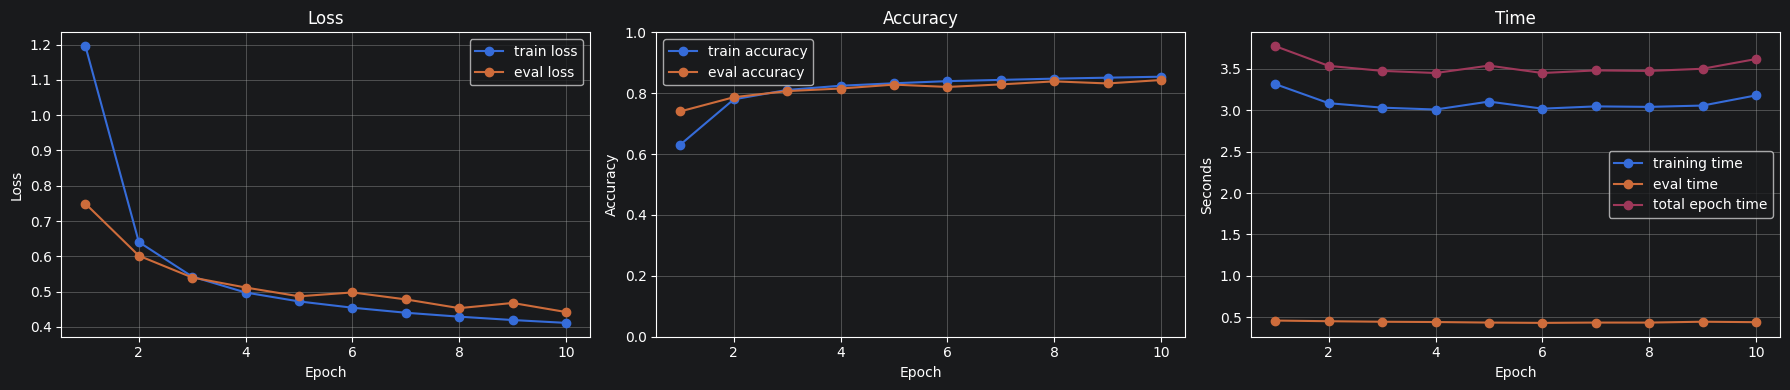

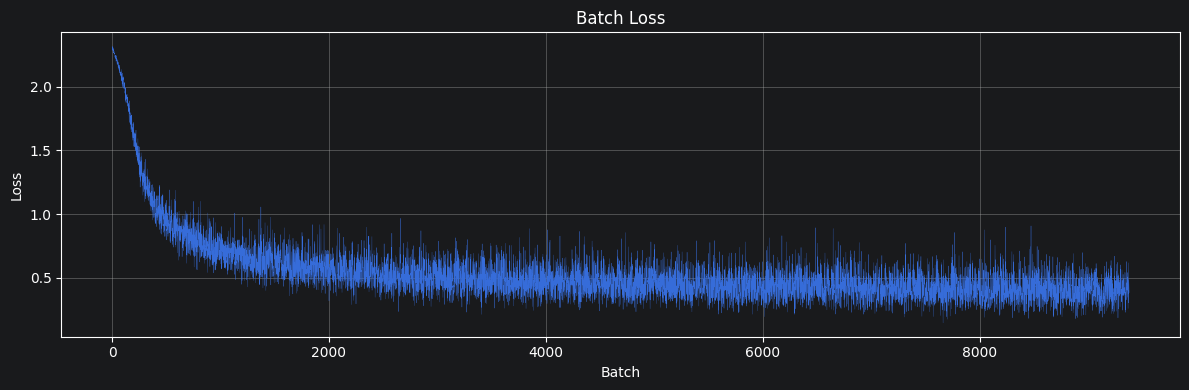

In [16]:
model = NN_DigitClassificator(layers=[64, 64], activation_functions=["relu", "selu"]).to(device)
print(model)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

history = train(model, train_dataloader, epochs=10, eval_dl=test_dataloader)
plot_history(history)